In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from scipy.stats import hypergeom
from sklearn.metrics import pairwise_distances
from itertools import combinations

from sklearn.manifold import MDS,Isomap,TSNE
from sklearn.cluster import AffinityPropagation,AgglomerativeClustering

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype' : 42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json
import re

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool

from adjustText import adjust_text
import umap

warnings.simplefilter("ignore")

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
annotation_file = "./full_annotation_df.csv"
annotation_df = pd.read_csv(annotation_file,index_col=[0,1]).reset_index(drop=True)
annotation_df.head()

,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993


In [3]:
annotation_df_TF = annotation_df[annotation_df["source"].apply(lambda x: ("TF" in x.split(",")) or ("TFPerturbSeq" in x.split(",")) )]

In [37]:
TF_list = np.unique(annotation_df_TF["closest_gene_target"])
TF_enhancer_list = np.unique(annotation_df_TF[annotation_df_TF["gene_target"].str.startswith("Element")]["gene_target"])

In [39]:
print(len(TF_list))
print(len(TF_enhancer_list))

110
981


In [5]:
dict_name_from_region = {}
for region_name in np.unique(annotation_df["intended_target_region"].values):
    if re.match("^OR[0-9]",region_name)!=None:
        dict_name_from_region[region_name] = region_name
    else:
        dict_name_from_region[region_name] = annotation_df[annotation_df["intended_target_region"]==region_name]["gene_target"].values[0]

dict_gene_from_region = {}
for region_name in np.unique(annotation_df["intended_target_region"].values):
    dict_gene_from_region[region_name] = annotation_df[annotation_df["intended_target_region"]==region_name]["closest_gene_target"].values[0]        

dict_region_from_name = {}
for target_name in np.unique(annotation_df["gene_target"].values):
    if re.match("^OR[0-9]",target_name)!=None:
        dict_name_from_region[target_name] = target_name
    else:
        dict_name_from_region[target_name] = annotation_df[annotation_df["gene_target"]==target_name]["intended_target_region"].values[0]

In [6]:
enhancer_info_norm_file = "./Step5_enhancer_pval_info.csv"
enhancer_info_norm = pd.read_csv(enhancer_info_norm_file,index_col=0)
enhancer_info_target = enhancer_info_norm[~enhancer_info_norm["is_NT"]]

### Load pySpade table

In [7]:
expression_cutoff = 0.01
fold_change_cutoff = 0.2
Significance_score_cutoff = -7
pval_cutoff = 0.001
hypergeom_pval_cutoff = -3

In [8]:
DATA_DIR = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240919_WTC11_lenti_CMProduction2/pySpade/'
local_hit_df = pd.read_csv(DATA_DIR + 'unfiltered_local_df.csv', index_col=0)

In [9]:
local_hit_df_select = local_hit_df[((local_hit_df['fc_by_rand_dist_cpm'] < (1-fold_change_cutoff)))\
                                   &(local_hit_df['Significance_score'] < Significance_score_cutoff)\
                                   &(local_hit_df['pval-empirical'] < pval_cutoff)
                                   &(local_hit_df['log(pval)-hypergeom'] < hypergeom_pval_cutoff)]
print(local_hit_df_select.shape)

(662, 17)


In [10]:
local_hit_df_select = local_hit_df_select[np.isin(local_hit_df_select["region"],annotation_df["intended_target_region"])].copy()
print(local_hit_df_select.shape)

(656, 17)


In [11]:
local_hit_df_select.head()

,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,distance,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg
123,CLDN6,chr16,2403462288,-,1,15,chr16:3009815-3010315,10256,1841,1750,-142.520158,0.401474,-133.571488,0.402652,0.0,72.877171,180.992931
374,DNAL1,chr14,2265052185,+,1,13,chr14:73644660-73645160,215,2578,2500,-9.418473,0.491561,-9.494132,0.490929,0.0,5.920554,12.059893
453,NEAT1,chr11,1874103825,+,0,10,chr11:65418756-65419256,4018,1644,1750,-21.071587,0.755516,-19.864572,0.757353,0.0,382.534474,505.093821
579,SLC35B1,chr17,2540489576,-,0,16,chr17:49707933-49708433,1081,1123,1000,-18.755035,0.416814,-17.521717,0.417842,0.0,16.057588,38.429837
897,ITGAV,chr2,435546487,+,1,1,chr2:186589862-186590362,203,3512,4000,-317.284167,0.176534,-297.679637,0.176815,0.0,14.258719,80.642187


In [12]:
local_hit_df_select["target_element"] = local_hit_df_select["region"].apply(lambda x: dict_name_from_region[x])
local_hit_df_select["target_gene"] = local_hit_df_select["region"].apply(lambda x: dict_gene_from_region[x])

In [13]:
local_hit_df_hits = local_hit_df_select[local_hit_df_select["gene_names"]==local_hit_df_select["target_gene"]]
local_hit_df_hits.shape

(310, 19)

In [14]:
#num of enhancer hits
local_hit_df_hits_promoter = local_hit_df_hits[~local_hit_df_hits["target_element"].str.startswith("Element")]
local_hit_df_hits_enhancer = local_hit_df_hits[local_hit_df_hits["target_element"].str.startswith("Element")]
local_hit_df_hits_enhancer_TF = local_hit_df_hits_enhancer[np.isin(local_hit_df_hits_enhancer["target_gene"],TF_list)]

print(local_hit_df_hits_promoter.shape)
print(local_hit_df_hits_enhancer.shape)
print(local_hit_df_hits_enhancer_TF.shape)

(161, 19)
(149, 19)
(100, 19)


In [15]:
local_hit_df_hits_enhancer_TF.head()

,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,distance,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,target_element,target_gene
1803,ZIC5,chr13,2177014891,-,0,12,chr13:99970268-99970768,1641,3818,4000,-12.146899,0.249103,-12.606067,0.246897,0.0,0.769078,3.114978,Element310,ZIC5
4814,TBX20,chr7,1267258450,-,0,6,chr7:35331886-35332717,77739,1879,2000,-26.976518,0.697241,-25.797459,0.698046,0.0,202.219997,289.694381,Element1102,TBX20
5109,ZBTB12,chr6,1093100316,-,1,5,chr6:31902033-31902533,41,6965,4000,-63.028820,0.254212,-42.854780,0.253967,0.0,2.358464,9.286502,Element1072,ZBTB12
7017,SOX4,chr6,1082791092,+,1,5,chr6:21593768-21594268,1000,2687,2500,-199.484472,0.436830,-194.793248,0.437661,0.0,134.014338,306.205794,Element1046,SOX4
7435,MEF2D,chr1,156500828,-,0,0,chr1:156500693-156501193,135,5188,4000,-70.152949,0.453944,-66.030187,0.455654,0.0,15.119504,33.181964,Element36,MEF2D


In [16]:
np.unique(local_hit_df_hits_enhancer_TF["target_gene"])

array(['ADNP2', 'AFF4', 'BNC1', 'BPTF', 'CAMTA2', 'CEBPG', 'CHAMP1',
       'CNBP', 'DNAJC1', 'GLI3', 'HAND2', 'HIF1A', 'HMG20A', 'HOXB4',
       'ISL1', 'KLF12', 'L3MBTL3', 'LEF1', 'LZTR1', 'MAFB', 'MBD6',
       'MEF2C', 'MEF2D', 'MEIS1', 'MLX', 'MTF2', 'MYOCD', 'MYRF',
       'NKX2-5', 'NKX2-6', 'PBX2', 'PCGF6', 'PHF21A', 'PITX2', 'RB1',
       'RBPJ', 'RCOR2', 'RNF2', 'SMAD4', 'SMAD5', 'SOX11', 'SOX4',
       'SUPT4H1', 'TAF5L', 'TBX2', 'TBX20', 'TBX5', 'TCF7', 'TFAP4',
       'TOPORS', 'TXNL4A', 'YWHAE', 'ZBTB10', 'ZBTB12', 'ZC3H15', 'ZFPM2',
       'ZIC5', 'ZNF133', 'ZNF148', 'ZNF184', 'ZNF20', 'ZNF425', 'ZNF436',
       'ZNF649', 'ZNF814'], dtype=object)

In [17]:
enhancer_hit_list_pyspade = np.unique(local_hit_df_hits_enhancer_TF["target_element"].values)
print(len(enhancer_hit_list_pyspade))

100


### Compare enhancer hits and energy distance hits

In [18]:
enhancer_info_target.head()

,promoter,enhancer,edist,pro_enh_dist,promoter_nontarget_pval,enhancer_nontarget_pval,promoter_nontarget_edist,enhancer_nontarget_edist,total_cell_num,edist_norm,target_name,expression_category,expression_level,expression_level_norm,is_NT
0,ACVR2B_P1P2,Element902,16.014038,65483,5.0,0.786854,16.725189,2.208496,4162,0.957480,ACVR2B,normal,83.014420,1.062110,False
1,ACVR2B_P1P2,Element903,20.124756,68764,5.0,1.147764,16.725189,2.895355,3901,1.203260,ACVR2B,normal,74.111350,0.948201,False
2,ACVR2B_P1P2,Element904,15.666748,75678,5.0,0.229840,16.725189,1.197150,4066,0.936716,ACVR2B,normal,88.973080,1.138346,False
3,ACVR2B_P1P2,Element905,13.641968,80241,5.0,0.912538,16.725189,2.190228,4344,0.815654,ACVR2B,normal,70.112206,0.897035,False
9,ADNP2_P1P2,Element694,15.442993,4709,5.0,0.279502,18.849921,1.269574,3253,0.819260,ADNP2,normal,20.127785,0.981589,False


In [48]:
dist_bins = [1000,5000,10000,50000,100000]
enhancer_info_target["dist_category"] = np.digitize(enhancer_info_target["pro_enh_dist"],dist_bins)

In [65]:
enhancer_info_TF = enhancer_info_target[np.isin(enhancer_info_target["target_name"],TF_list)].copy()
enhancer_info_hits = enhancer_info_target[(enhancer_info_target["edist_norm"]<0.7)].copy()
enhancer_info_hits_TF = enhancer_info_target[(enhancer_info_target["edist_norm"]<0.7) &
                                             (np.isin(enhancer_info_target["target_name"],TF_list))
                                            ].copy()
print(enhancer_info_TF.shape)
print(enhancer_info_hits.shape)
print(enhancer_info_hits_TF.shape)

(748, 16)
(234, 16)
(207, 16)


In [66]:
enhancer_all_list_edist = np.unique(enhancer_info_TF["enhancer"].values)
enhancer_hit_list_edist = np.unique(enhancer_info_hits_TF["enhancer"].values)
print(len(enhancer_all_list_edist))
print(len(enhancer_hit_list_edist))

748
207


In [67]:
enhancer_hit_list_pyspade_testset = set(enhancer_all_list_edist) & set(enhancer_hit_list_pyspade)
non_sig_enh = set(enhancer_hit_list_pyspade)-set(enhancer_all_list_edist)
print("overlap",len(enhancer_hit_list_pyspade_testset))
print("non_sig_hit",len(non_sig_enh))

overlap 76
non_sig_hit 24


In [68]:
print("overlap",len(set(enhancer_hit_list_edist) & set(enhancer_hit_list_pyspade)))
print("edist_only",len(set(enhancer_hit_list_edist) - set(enhancer_hit_list_pyspade_testset)))
print("pyspade_only",len(set(enhancer_hit_list_pyspade_testset)-set(enhancer_hit_list_edist)))

overlap 59
edist_only 148
pyspade_only 17


### analysis e-distance vs expression

In [53]:
edist_stat_df = pd.DataFrame(columns=["dist1","dist2","dist3","dist4","dist5","dist6"])

In [54]:
edist_stat_df.loc["total",:] = \
    np.unique(enhancer_info_TF["dist_category"],return_counts=True)[1]
print("total",enhancer_info_TF.shape)

enhancer_info_cutoff_sig = enhancer_info_TF[enhancer_info_TF["enhancer_nontarget_pval"]>3]
edist_stat_df.loc["sig",:] = \
    np.unique(enhancer_info_cutoff_sig["dist_category"],return_counts=True)[1]
print("edist_sig",enhancer_info_cutoff_sig.shape)


enhancer_info_cutoff_pyspade = enhancer_info_TF[np.isin(enhancer_info_TF["enhancer"],enhancer_hit_list_pyspade)]
edist_stat_df.loc["pyspade",:] = \
    np.unique(enhancer_info_cutoff_pyspade["dist_category"],return_counts=True)[1]
print("pyspade",enhancer_info_cutoff_pyspade.shape)

enhancer_info_cutoff_edist = enhancer_info_TF[enhancer_info_TF["edist_norm"]<0.70]
edist_stat_df.loc["edist_level",:] = \
    np.unique(enhancer_info_cutoff_edist["dist_category"],return_counts=True)[1]
print("edist_norm",enhancer_info_cutoff_edist.shape)

total (748, 16)
edist_sig (130, 16)
pyspade (76, 16)
edist_norm (207, 16)


In [55]:
# enhancer_info_cutoff_exp = enhancer_info_TF[enhancer_info_TF["expression_level_norm"]<0.9]
# print(enhancer_info_cutoff_exp.shape)
# edist_stat_df.loc["exp_level",:] = \
#     np.unique(enhancer_info_cutoff_exp["dist_category"],return_counts=True)[1]

In [56]:
edist_stat_df["sum"] = edist_stat_df.apply(lambda x:x.sum(),axis=1)

In [61]:
edist_stat_df_ratio = edist_stat_df.apply(lambda x: x/x["sum"]*100,axis=1)
edist_stat_df_ratio = edist_stat_df_ratio.iloc[:,:-1] 

In [62]:
edist_stat_df_ratio

,dist1,dist2,dist3,dist4,dist5,dist6
total,15.106952,6.818182,5.213904,23.930481,27.139037,21.791444
sig,46.153846,7.692308,5.384615,13.846154,22.307692,4.615385
pyspade,73.684211,13.157895,5.263158,2.631579,3.947368,1.315789
edist_level,31.400966,12.077295,3.864734,18.840580,20.289855,13.526570


In [63]:
edist_stat_df_melt = edist_stat_df_ratio.melt(ignore_index=False).reset_index()

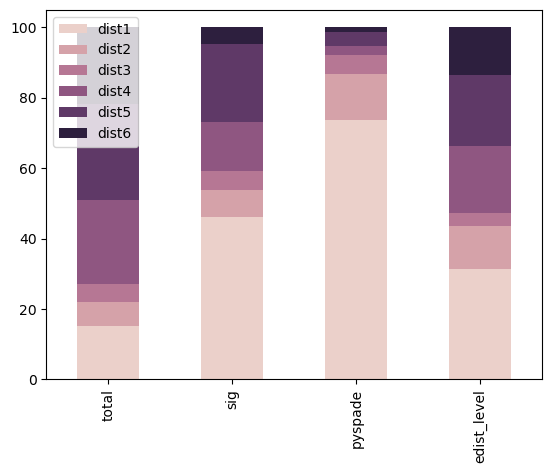

In [64]:
colors = ['#EBD0CA', '#D5A2A9', '#B67794', '#8F5681', '#5F3967', '#2D1F3E']
from matplotlib.colors import ListedColormap
cmap = ListedColormap(colors)

edist_stat_df_ratio.plot(kind='bar', stacked=True,colormap=cmap)
plt.savefig("figures/enhancer_comparison.pdf")

### Plot feature plots for hits

In [70]:
#remove outlier value
enhancer_info_norm_clear = enhancer_info_target[(enhancer_info_target["expression_level_norm"]<2) &
                                                (enhancer_info_target["edist_norm"]<2) &
                                                (enhancer_info_target["expression_category"]!="low")
                                               ]

In [93]:
def get_category_of_hits(enh_name):
    if (enh_name in enhancer_hit_list_pyspade) and (enh_name in enhancer_hit_list_edist):
        return "Both"
    elif (enh_name in enhancer_hit_list_pyspade):
        return "pyspade"
    elif (enh_name in enhancer_hit_list_edist):
        return "e-dist"
    else:
        return "None"

enhancer_info_norm_clear["hits_cat"] = [get_category_of_hits(enh_name) \
                                        for enh_name in enhancer_info_norm_clear["enhancer"]]

In [94]:
enhancer_info_hits

,promoter,enhancer,edist,pro_enh_dist,promoter_nontarget_pval,enhancer_nontarget_pval,promoter_nontarget_edist,enhancer_nontarget_edist,total_cell_num,edist_norm,target_name,expression_category,expression_level,expression_level_norm,is_NT,dist_category
11,ADNP2_P1P2,Element696,10.671631,7,5.000000,2.718967,18.849921,3.490594,4630,0.566137,ADNP2,normal,9.139147,0.445697,False,0
32,BNC1_P1P2,Element408,7.378418,88325,5.000000,1.608888,13.398584,5.125836,2656,0.550686,BNC1,normal,11.889888,0.791476,False,4
33,BNC1_P1P2,Element409,1.870850,58976,5.000000,5.000000,13.398584,7.876129,4264,0.139630,BNC1,normal,12.845839,0.855110,False,4
34,BNC1_P1P2,Element410,5.485352,503,5.000000,3.214670,13.398584,6.080249,3608,0.409398,BNC1,normal,4.589603,0.305517,False,0
35,BNC1_P1P2,Element411,3.486938,76,5.000000,5.000000,13.398584,25.923962,2949,0.260247,BNC1,normal,2.738139,0.182270,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,ZNF814_P1P2,Element766,4.476318,30077,4.221849,0.394253,7.767151,1.465204,3641,0.576314,ZNF814,normal,66.763930,0.901247,False,3
1296,ZNF814_P1P2,Element767,4.558838,42636,4.221849,0.855083,7.767151,2.599023,3048,0.586938,ZNF814,normal,57.268430,0.773067,False,3
1297,ZNF814_P1P2,Element768,2.525391,97575,4.221849,5.000000,7.767151,8.225720,3849,0.325137,ZNF814,normal,71.843780,0.969820,False,4
1304,ZSCAN10_P1P2,Element447,4.819458,574,5.000000,5.000000,37.051440,23.916223,3477,0.130075,ZSCAN10,low,0.000000,0.000000,False,0


In [95]:
enhancer_info_norm_clear["is_significance"] = enhancer_info_norm_clear["enhancer_nontarget_pval"]>3

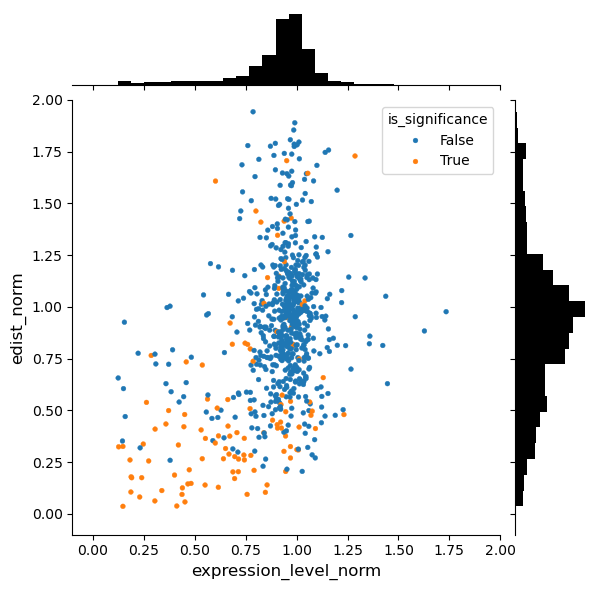

In [96]:
g = sns.JointGrid(data=enhancer_info_norm_clear, x="expression_level_norm",y="edist_norm")

g.ax_joint.set_xlim(-0.1,2)
g.ax_joint.set_ylim(-0.1,2)
sns.scatterplot(data=enhancer_info_norm_clear, x="expression_level_norm",y="edist_norm",
                hue="is_significance",
                edgecolor=None,s=12,color="black",ax=g.ax_joint)

g.ax_marg_x.hist(enhancer_info_norm_clear["expression_level_norm"],
                 bins=25, color="black")
g.ax_marg_y.hist(enhancer_info_norm_clear["edist_norm"],
                 bins=25, color="black", orientation="horizontal")
plt.savefig("Step5_pro_enh_edist_significant.pdf")

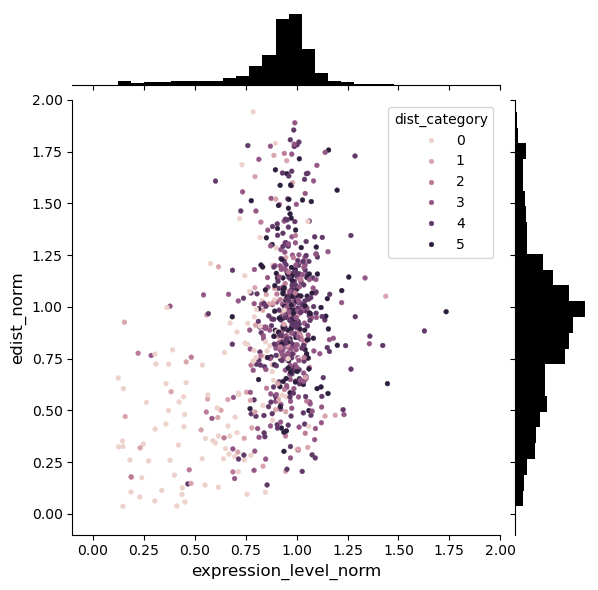

In [97]:
g = sns.JointGrid(data=enhancer_info_norm_clear, x="expression_level_norm",y="edist_norm")

g.ax_joint.set_xlim(-0.1,2)
g.ax_joint.set_ylim(-0.1,2)
sns.scatterplot(data=enhancer_info_norm_clear, x="expression_level_norm",y="edist_norm",
                hue="dist_category",
                edgecolor=None,s=12,color="black",ax=g.ax_joint)

g.ax_marg_x.hist(enhancer_info_norm_clear["expression_level_norm"],
                 bins=25, color="black")
g.ax_marg_y.hist(enhancer_info_norm_clear["edist_norm"],
                 bins=25, color="black", orientation="horizontal")
plt.savefig("Step5_pro_enh_edist_expression_dist.pdf")

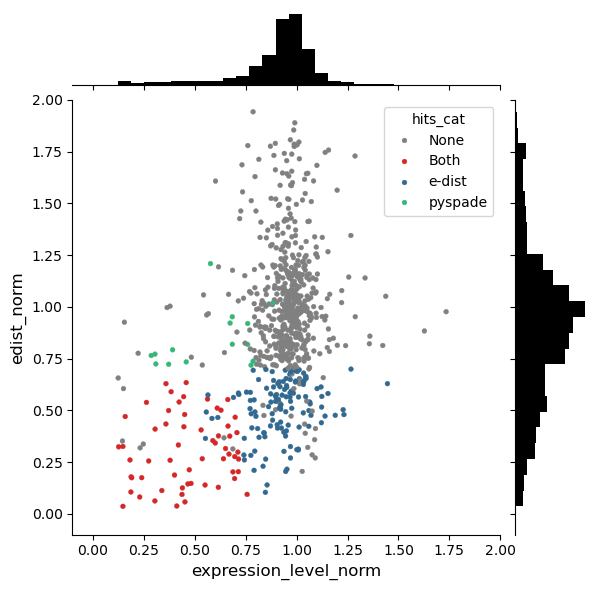

In [99]:
color_pallette = ["#808080","#D62728","#316990","#36B779"] #None, Both, pyspade,edist

g = sns.JointGrid(data=enhancer_info_norm_clear, x="expression_level_norm",y="edist_norm")

g.ax_joint.set_xlim(-0.1,2)
g.ax_joint.set_ylim(-0.1,2)
sns.scatterplot(data=enhancer_info_norm_clear, x="expression_level_norm",y="edist_norm",
                hue="hits_cat",palette=color_pallette,
                hue_order=["None","Both","e-dist","pyspade"],
                edgecolor=None,s=12,color="black",ax=g.ax_joint)

g.ax_marg_x.hist(enhancer_info_norm_clear["expression_level_norm"],
                 bins=25, color="black")
g.ax_marg_y.hist(enhancer_info_norm_clear["edist_norm"],
                 bins=25, color="black", orientation="horizontal")
plt.savefig("Step5_pro_enh_edist_is_sig_norm_edist.pdf")